# Pokemon Evolution Stage Classifier

Pulls base stats from the [PokeAPI](https://pokeapi.co/), labels each Pokemon by evolution stage (1, 2, 3, or Legendary), trains a classifier on Gen 1-3, then tests it on Gen 4 to see how well it generalizes.

## 1. Install & Import Libraries

In [66]:
# Install required packages if needed
# !pip install requests pandas scikit-learn matplotlib seaborn tqdm

import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline

print('Libraries loaded.')

Libraries loaded.


## 2. Fetch Data

Gen 1-3 (IDs 1-386) is used for training and internal testing. Gen 4 (IDs 387-493) is held out entirely for the generalization test.

Stage labels: 1 = base, 2 = first evo, 3 = second evo, 4 = Legendary/Mythical

In [67]:
BASE_URL = 'https://pokeapi.co/api/v2'

# Generation ID ranges
GEN_1_3_RANGE = range(1, 387)    # 386 Pokémon
GEN_4_RANGE   = range(387, 494)  # 107 Pokémon

def get_pokemon_stats(pokemon_id):
    """Fetch base stats and species info for a single Pokémon."""
    url = f'{BASE_URL}/pokemon/{pokemon_id}'
    resp = requests.get(url, timeout=10)
    if resp.status_code != 200:
        return None
    data = resp.json()

    stats = {s['stat']['name']: s['base_stat'] for s in data['stats']}
    return {
        'id': data['id'],
        'name': data['name'],
        'hp': stats.get('hp', 0),
        'attack': stats.get('attack', 0),
        'defense': stats.get('defense', 0),
        'special_attack': stats.get('special-attack', 0),
        'special_defense': stats.get('special-defense', 0),
        'speed': stats.get('speed', 0),
        'total': sum(stats.values()),
        'base_experience': data.get('base_experience') or 0,
        'weight': data.get('weight', 0),
        'height': data.get('height', 0),
        'species_url': data['species']['url']
    }

def get_evolution_stage(species_url):
    """
    Determine evolution stage:
      4 = Legendary or Mythical (short-circuits chain lookup)
      1 = Base form
      2 = 1st evolution
      3 = 2nd evolution (capped)
    """
    try:
        species_data = requests.get(species_url, timeout=10).json()

        # check legendary/mythical flags before walking the chain
        if species_data.get('is_legendary') or species_data.get('is_mythical'):
            return 4

        chain_url = species_data['evolution_chain']['url']
        chain = requests.get(chain_url, timeout=10).json()['chain']
        target_name = species_data['name']

        def find_stage(node, stage=1):
            if node['species']['name'] == target_name:
                return stage
            for evo in node.get('evolves_to', []):
                result = find_stage(evo, stage + 1)
                if result:
                    return result
            return None

        stage = find_stage(chain)
        return min(stage, 3) if stage else 1
    except:
        return None

print('API functions defined.')

API functions defined.


In [68]:
def fetch_generation(id_range, label):
    """Fetch stats and evolution stages for a range of Pokémon IDs."""
    print(f'Fetching {label} stats...')
    pokemon_list = []
    for i in tqdm(id_range):
        data = get_pokemon_stats(i)
        if data:
            pokemon_list.append(data)
        time.sleep(0.05)

    print(f'Fetching {label} evolution stages...')
    for poke in tqdm(pokemon_list):
        poke['evolution_stage'] = get_evolution_stage(poke['species_url'])
        time.sleep(0.07)

    df = pd.DataFrame(pokemon_list)
    df = df.dropna(subset=['evolution_stage'])
    df['evolution_stage'] = df['evolution_stage'].astype(int)
    df = df.drop(columns=['species_url'])
    print(f'{label} done — {df.shape[0]} Pokemon loaded.')
    return df

# Fetch both generations
df_gen13 = fetch_generation(GEN_1_3_RANGE, 'Gen 1–3')
df_gen4  = fetch_generation(GEN_4_RANGE,   'Gen 4')

Fetching Gen 1–3 stats...


  0%|          | 0/386 [00:00<?, ?it/s]

Fetching Gen 1–3 evolution stages...


  0%|          | 0/386 [00:00<?, ?it/s]

Gen 1–3 done — 386 Pokemon loaded.
Fetching Gen 4 stats...


  0%|          | 0/107 [00:00<?, ?it/s]

Fetching Gen 4 evolution stages...


  0%|          | 0/107 [00:00<?, ?it/s]

Gen 4 done — 107 Pokemon loaded.


## 3. Exploratory Data Analysis

In [69]:
# Dataset overview
print('=== Gen 1–3 Dataset ===')
print(df_gen13['evolution_stage'].value_counts().sort_index())
print('\n=== Gen 4 Dataset ===')
print(df_gen4['evolution_stage'].value_counts().sort_index())

=== Gen 1–3 Dataset ===
evolution_stage
1    174
2    145
3     46
4     21
Name: count, dtype: int64

=== Gen 4 Dataset ===
evolution_stage
1    38
2    39
3    16
4    14
Name: count, dtype: int64


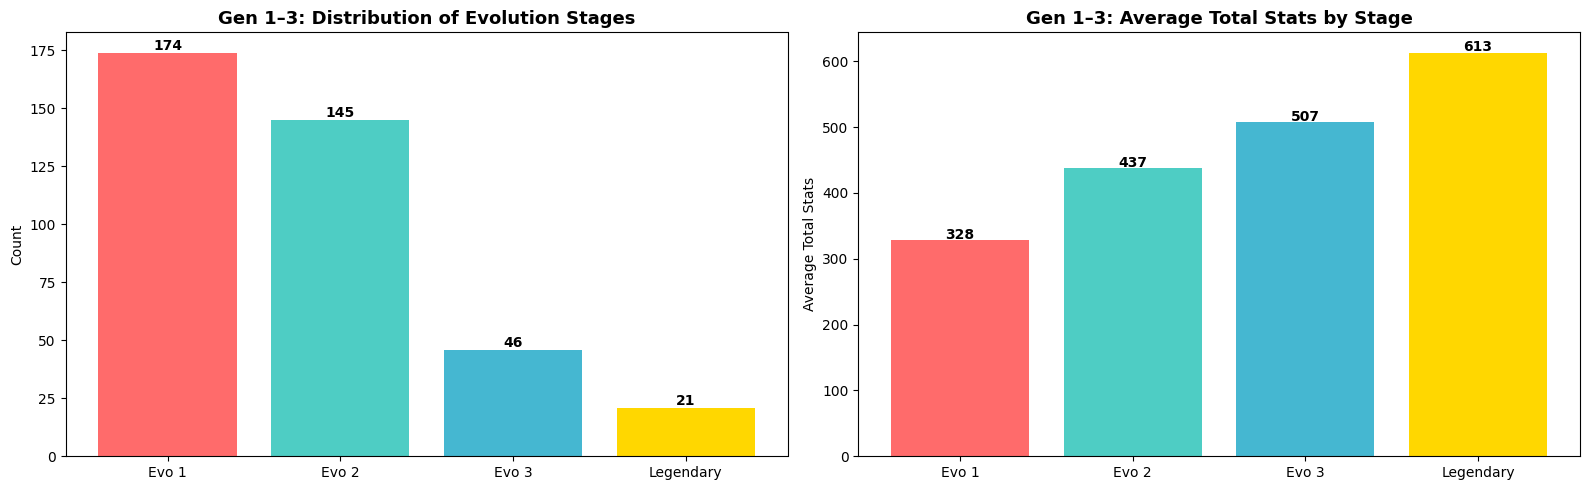

In [70]:
STAGE_LABELS = {
    1: 'Evo 1',
    2: 'Evo 2',
    3: 'Evo 3',
    4: 'Legendary'
}

STAGE_LABELS_TEXT = {
    1: 'Evo 1',
    2: 'Evo 2',
    3: 'Evo 3',
    4: 'Legendary'
}
COLORS = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFD700']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

stage_counts = df_gen13['evolution_stage'].value_counts().sort_index()
axes[0].bar([STAGE_LABELS[s] for s in stage_counts.index], stage_counts.values, color=COLORS[:len(stage_counts)])
axes[0].set_title('Gen 1–3: Distribution of Evolution Stages', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(stage_counts.values):
    axes[0].text(i, v + 1, str(v), ha='center', fontweight='bold')

avg_stats = df_gen13.groupby('evolution_stage')['total'].mean()
axes[1].bar([STAGE_LABELS[s] for s in avg_stats.index], avg_stats.values, color=COLORS[:len(avg_stats)])
axes[1].set_title('Gen 1–3: Average Total Stats by Stage', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Average Total Stats')
for i, v in enumerate(avg_stats.values):
    axes[1].text(i, v + 2, f'{v:.0f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

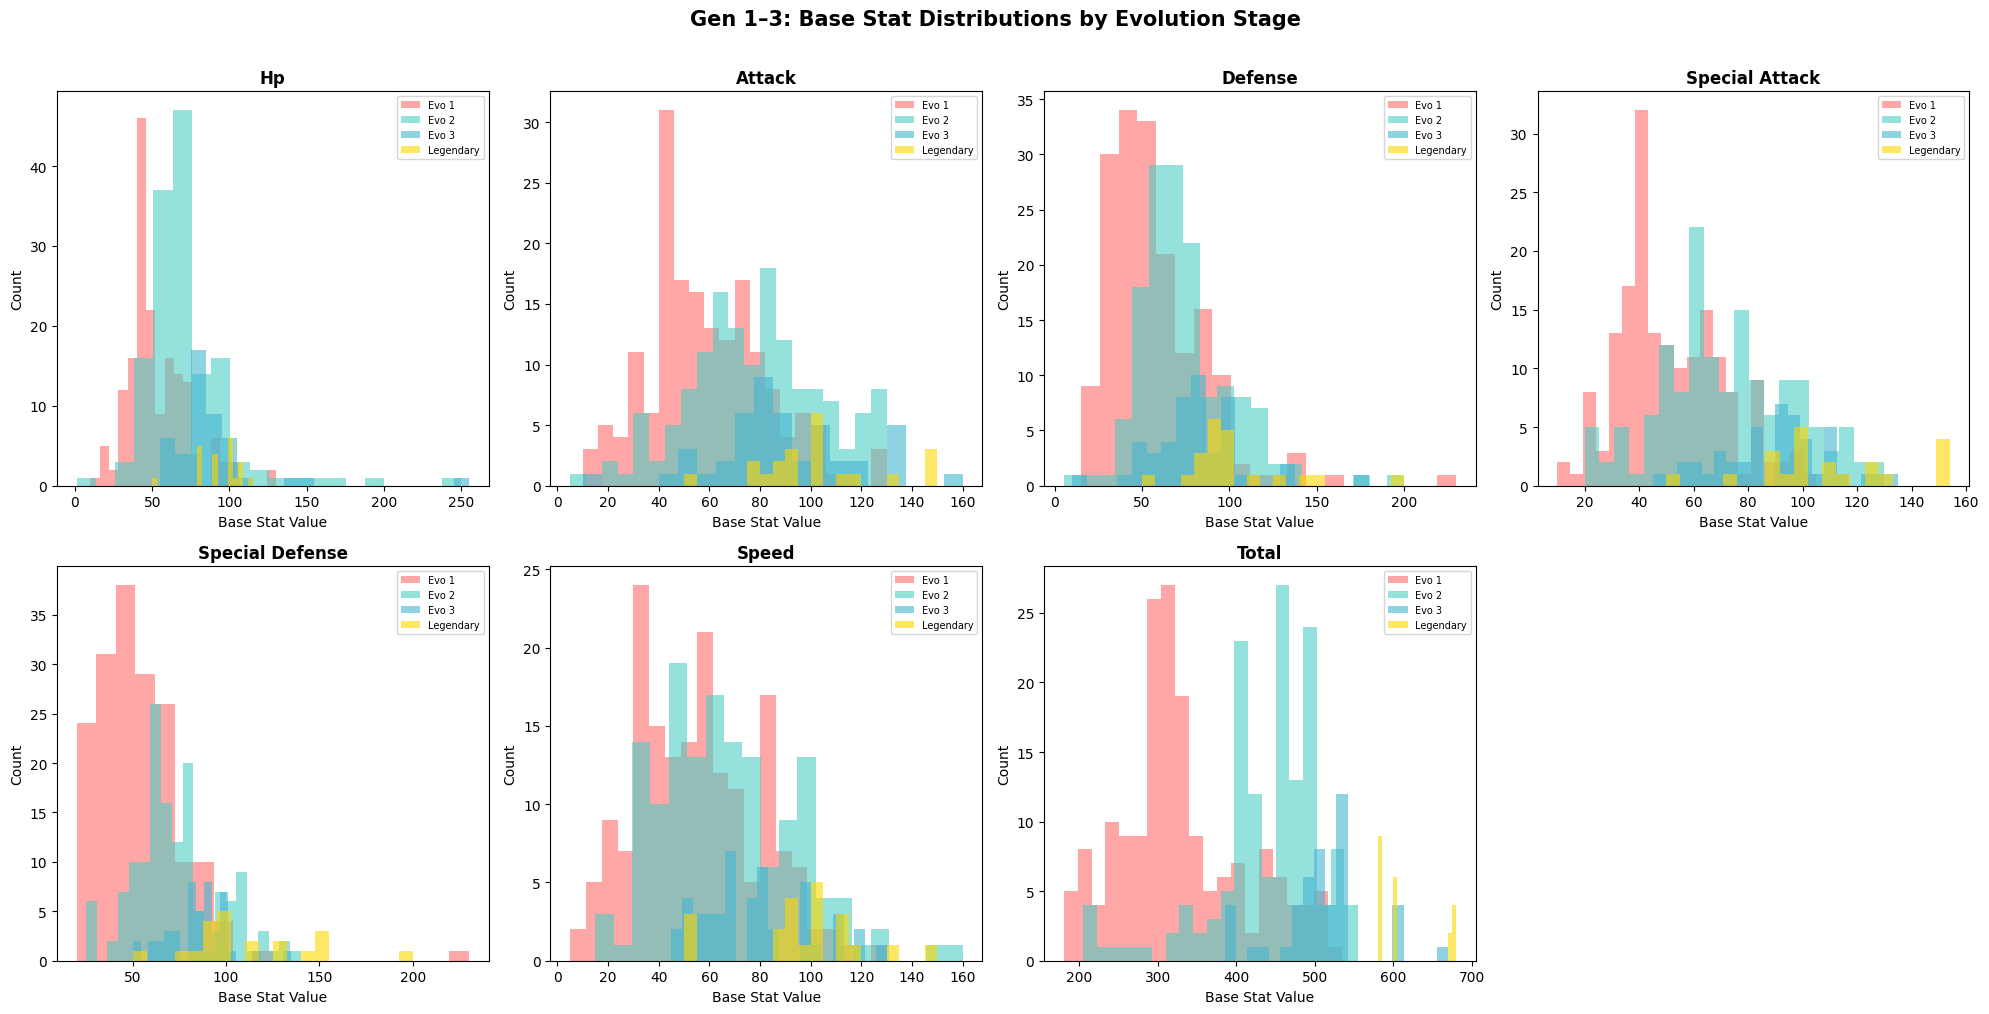

In [71]:
# Stat distributions by evolution stage (all 4 classes)
stat_cols = ['hp', 'attack', 'defense', 'special_attack', 'special_defense', 'speed', 'total']
stage_palette = {1: '#FF6B6B', 2: '#4ECDC4', 3: '#45B7D1', 4: '#FFD700'}

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for idx, stat in enumerate(stat_cols):
    ax = axes[idx]
    for stage in sorted(df_gen13['evolution_stage'].unique()):
        subset = df_gen13[df_gen13['evolution_stage'] == stage][stat]
        ax.hist(subset, alpha=0.6, bins=20, label=STAGE_LABELS[stage], color=stage_palette[stage])
    ax.set_title(stat.replace('_', ' ').title(), fontsize=12, fontweight='bold')
    ax.set_xlabel('Base Stat Value')
    ax.set_ylabel('Count')
    ax.legend(fontsize=7)

axes[-1].set_visible(False)
fig.suptitle('Gen 1–3: Base Stat Distributions by Evolution Stage', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

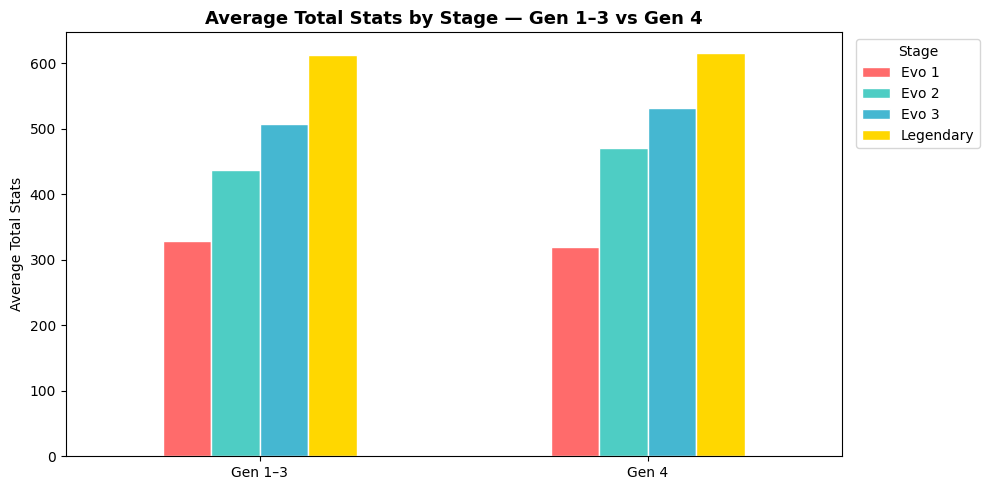

In [72]:
# Compare Gen 1-3 vs Gen 4 average stats side by side
df_gen13['gen'] = 'Gen 1–3'
df_gen4['gen']  = 'Gen 4'
df_combined = pd.concat([df_gen13, df_gen4], ignore_index=True)

fig, ax = plt.subplots(figsize=(10, 5))
gen_avg = df_combined.groupby(['gen', 'evolution_stage'])['total'].mean().unstack()
gen_avg.columns = [STAGE_LABELS[c] for c in gen_avg.columns]
gen_avg.plot(kind='bar', ax=ax, color=COLORS[:len(gen_avg.columns)], edgecolor='white')
ax.set_title('Average Total Stats by Stage — Gen 1–3 vs Gen 4', fontsize=13, fontweight='bold')
ax.set_ylabel('Average Total Stats')
ax.set_xlabel('')
ax.legend(title='Stage', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

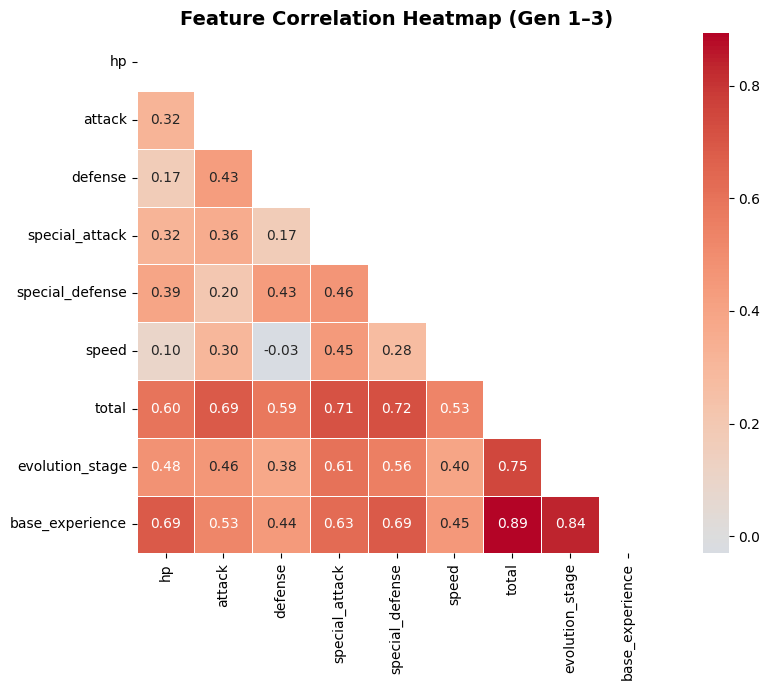

In [73]:
# Correlation heatmap (Gen 1–3 training data)
plt.figure(figsize=(10, 7))
corr_cols = stat_cols + ['evolution_stage', 'base_experience']
corr = df_gen13[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Feature Correlation Heatmap (Gen 1–3)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Feature Engineering & Train/Test Split

In [74]:
FEATURES = ['hp', 'attack', 'defense', 'special_attack', 'special_defense',
            'speed','total', 'weight', 'height'] #Removed base_exp due to having almost 1 for 1 correlation with evolution stage
TARGET = 'evolution_stage'

# Gen 1–3: split into train (80%) and internal test (20%)
X_gen13 = df_gen13[FEATURES]
y_gen13 = df_gen13[TARGET]

X_train, X_test_gen13, y_train, y_test_gen13 = train_test_split(
    X_gen13, y_gen13, test_size=0.2, random_state=42, stratify=y_gen13
)

# Gen 4: entirely unseen — used only for final generalization test
X_test_gen4 = df_gen4[FEATURES]
y_test_gen4 = df_gen4[TARGET]

print(f'Training set (Gen 1–3):          {X_train.shape[0]} Pokémon')
print(f'Internal test set (Gen 1–3):     {X_test_gen13.shape[0]} Pokémon')
print(f'Generalization test set (Gen 4): {X_test_gen4.shape[0]} Pokémon')
print(f'\nTraining class distribution:')
print(y_train.value_counts().sort_index().rename(STAGE_LABELS_TEXT))

Training set (Gen 1–3):          308 Pokémon
Internal test set (Gen 1–3):     78 Pokémon
Generalization test set (Gen 4): 107 Pokémon

Training class distribution:
evolution_stage
Evo 1        139
Evo 2        115
Evo 3         37
Legendary     17
Name: count, dtype: int64


## 5. Train & Compare Models

In [75]:
# Note: class_weight='balanced' is important since Legendary is a small class
models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'))
    ]),
    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced'))
    ]),
    'Gradient Boosting': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', GradientBoostingClassifier(n_estimators=200, random_state=42))
    ])
}

print('Cross-Validation Results (5-fold on Gen 1–3 training set):\n')
cv_results = {}
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    cv_results[name] = scores
    print(f'{name}:')
    print(f'  Accuracy: {scores.mean():.3f} ± {scores.std():.3f}')
    print()

Cross-Validation Results (5-fold on Gen 1–3 training set):

Logistic Regression:
  Accuracy: 0.662 ± 0.064

Random Forest:
  Accuracy: 0.773 ± 0.048

Gradient Boosting:
  Accuracy: 0.718 ± 0.035



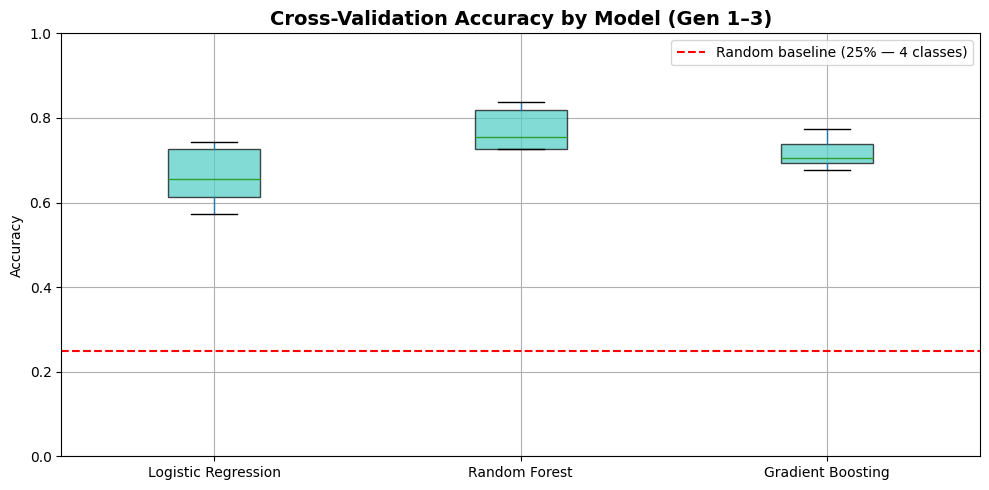

In [76]:
# Visualize CV comparison
fig, ax = plt.subplots(figsize=(10, 5))
cv_df = pd.DataFrame(cv_results)
cv_df.boxplot(ax=ax, patch_artist=True, boxprops=dict(facecolor='#4ECDC4', alpha=0.7))
ax.set_title('Cross-Validation Accuracy by Model (Gen 1–3)', fontsize=14, fontweight='bold')
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1)
ax.axhline(y=0.25, color='red', linestyle='--', label='Random baseline (25% — 4 classes)')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Best Model — Gen 1–3 Evaluation

In [77]:
# Select and train best model
best_name = max(cv_results, key=lambda k: cv_results[k].mean())
best_model = models[best_name]
best_model.fit(X_train, y_train)

y_pred_gen13 = best_model.predict(X_test_gen13)
acc_gen13 = (y_pred_gen13 == y_test_gen13).mean()

TARGET_NAMES = list(STAGE_LABELS_TEXT.values())

print(f'Best model: {best_name}')
print(f'Gen 1–3 Test Accuracy: {acc_gen13:.3f}\n')
print('Classification Report (Gen 1–3 holdout):')
print(classification_report(y_test_gen13, y_pred_gen13, target_names=TARGET_NAMES))

Best model: Random Forest
Gen 1–3 Test Accuracy: 0.808

Classification Report (Gen 1–3 holdout):
              precision    recall  f1-score   support

       Evo 1       0.90      0.77      0.83        35
       Evo 2       0.70      0.87      0.78        30
       Evo 3       0.86      0.67      0.75         9
   Legendary       1.00      1.00      1.00         4

    accuracy                           0.81        78
   macro avg       0.86      0.83      0.84        78
weighted avg       0.82      0.81      0.81        78



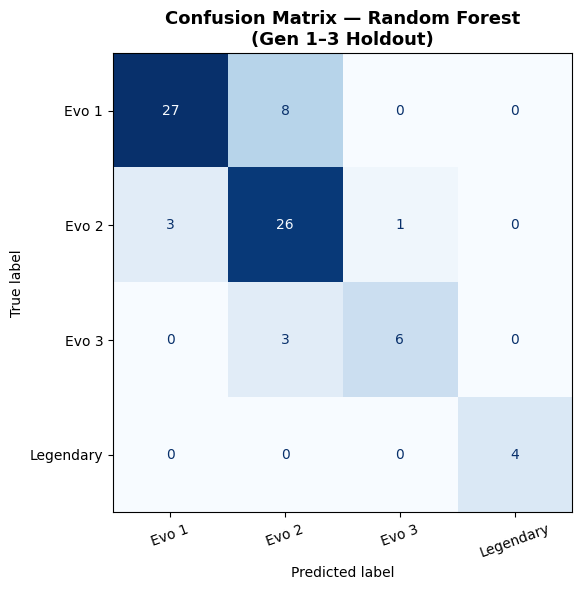

In [78]:
# Confusion matrix — Gen 1–3 test set
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test_gen13, y_pred_gen13)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=TARGET_NAMES).plot(
    ax=ax, cmap='Blues', colorbar=False
)
ax.set_title(f'Confusion Matrix — {best_name}\n(Gen 1–3 Holdout)', fontsize=13, fontweight='bold')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

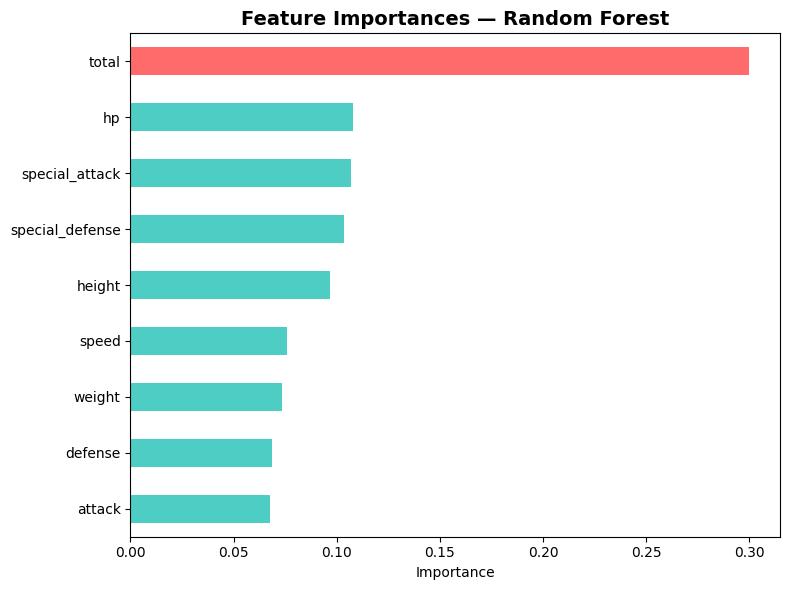

Top 3 most important features:
  total: 0.300
  hp: 0.108
  special_attack: 0.107


In [79]:
# Feature importance
clf = best_model.named_steps['clf']
if hasattr(clf, 'feature_importances_'):
    importances = pd.Series(clf.feature_importances_, index=FEATURES).sort_values(ascending=True)
    fig, ax = plt.subplots(figsize=(8, 6))
    colors_bar = ['#FF6B6B' if i == importances.index[-1] else '#4ECDC4' for i in importances.index]
    importances.plot(kind='barh', ax=ax, color=colors_bar)
    ax.set_title(f'Feature Importances — {best_name}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.show()

    print('Top 3 most important features:')
    for feat, imp in importances.sort_values(ascending=False).head(3).items():
        print(f'  {feat}: {imp:.3f}')

## 7. Gen 4 Generalization Test

The model was trained only on Gen 1-3. This tests it against Gen 4 Pokemon it has never seen — if accuracy holds up, the stat patterns are consistent across generations.

In [80]:
y_pred_gen4 = best_model.predict(X_test_gen4)
acc_gen4 = (y_pred_gen4 == y_test_gen4).mean()

print(f'Gen 4 Generalization Accuracy: {acc_gen4:.3f}')
print(f'Gen 1–3 Holdout Accuracy:      {acc_gen13:.3f}')
print(f'Accuracy drop:                 {acc_gen13 - acc_gen4:.3f}\n')
print('Classification Report (Gen 4 — unseen):')
print(classification_report(y_test_gen4, y_pred_gen4, target_names=TARGET_NAMES))

Gen 4 Generalization Accuracy: 0.822
Gen 1–3 Holdout Accuracy:      0.808
Accuracy drop:                 -0.015

Classification Report (Gen 4 — unseen):
              precision    recall  f1-score   support

       Evo 1       0.92      0.95      0.94        38
       Evo 2       0.73      0.85      0.79        39
       Evo 3       0.67      0.38      0.48        16
   Legendary       0.93      0.93      0.93        14

    accuracy                           0.82       107
   macro avg       0.81      0.77      0.78       107
weighted avg       0.82      0.82      0.81       107



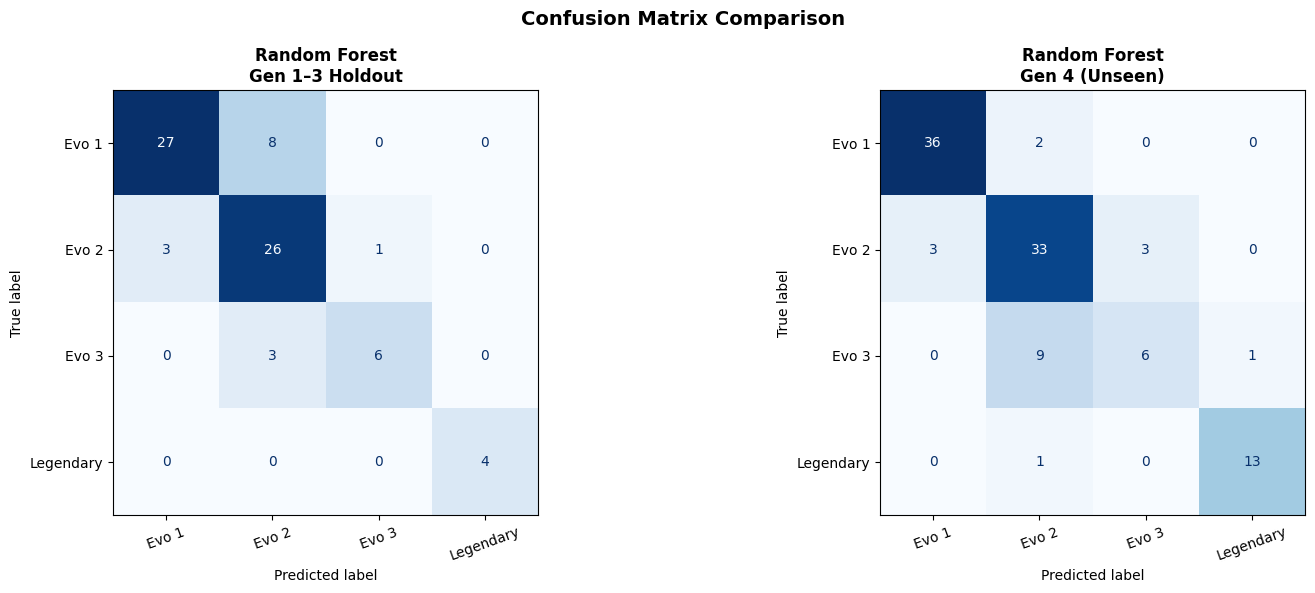

In [81]:
# Side-by-side confusion matrices: Gen 1-3 holdout vs Gen 4
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, y_true, y_pred, title in [
    (axes[0], y_test_gen13, y_pred_gen13, f'{best_name}\nGen 1–3 Holdout'),
    (axes[1], y_test_gen4,  y_pred_gen4,  f'{best_name}\nGen 4 (Unseen)')
]:
    cm = confusion_matrix(y_true, y_pred)
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=TARGET_NAMES).plot(
        ax=ax, cmap='Blues', colorbar=False
    )
    ax.set_title(title, fontsize=12, fontweight='bold')
    plt.setp(ax.get_xticklabels(), rotation=20)

plt.suptitle('Confusion Matrix Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

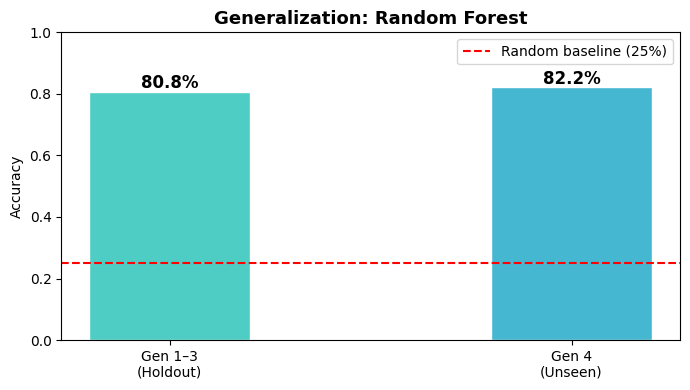

In [82]:
# Accuracy comparison bar chart
fig, ax = plt.subplots(figsize=(7, 4))
accs = [acc_gen13, acc_gen4]
labels = ['Gen 1–3\n(Holdout)', 'Gen 4\n(Unseen)']
bars = ax.bar(labels, accs, color=['#4ECDC4', '#45B7D1'], width=0.4, edgecolor='white')
ax.set_ylim(0, 1)
ax.set_ylabel('Accuracy')
ax.set_title(f'Generalization: {best_name}', fontsize=13, fontweight='bold')
ax.axhline(y=0.25, color='red', linestyle='--', label='Random baseline (25%)')
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width() / 2, acc + 0.01, f'{acc:.1%}',
            ha='center', fontweight='bold', fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()

In [83]:
# Show which Gen 4 Pokémon the model got wrong
gen4_results = df_gen4[['name', 'total', 'evolution_stage']].copy()
gen4_results['predicted'] = y_pred_gen4
gen4_results['correct'] = gen4_results['evolution_stage'] == gen4_results['predicted']
gen4_results['true_label'] = gen4_results['evolution_stage'].map(STAGE_LABELS_TEXT)
gen4_results['pred_label'] = gen4_results['predicted'].map(STAGE_LABELS_TEXT)

misclassified = gen4_results[~gen4_results['correct']].sort_values('total', ascending=False)
print(f'Gen 4 misclassified: {len(misclassified)} / {len(gen4_results)} Pokémon\n')
print(misclassified[['name', 'total', 'true_label', 'pred_label']].to_string(index=False))

Gen 4 misclassified: 19 / 107 Pokémon

      name  total true_label pred_label
  garchomp    600      Evo 3  Legendary
 magnezone    535      Evo 3      Evo 2
 porygon-z    535      Evo 3      Evo 2
 rhyperior    535      Evo 3      Evo 2
 mamoswine    530      Evo 3      Evo 2
  torterra    525      Evo 3      Evo 2
  dusknoir    525      Evo 3      Evo 2
   gallade    518      Evo 3      Evo 2
   yanmega    515      Evo 2      Evo 3
  roserade    515      Evo 3      Evo 2
lickilicky    515      Evo 2      Evo 3
   gliscor    510      Evo 2      Evo 1
 toxicroak    490      Evo 2      Evo 3
 spiritomb    485      Evo 1      Evo 2
 staraptor    485      Evo 3      Evo 2
    phione    480  Legendary      Evo 2
 carnivine    454      Evo 1      Evo 2
   cherrim    450      Evo 2      Evo 1
  staravia    340      Evo 2      Evo 1


## 8. Predict Any Pokémon

In [86]:
def predict_evolution_stage(name_or_id):
    """Predict the evolution stage of any Pokémon by name or ID."""
    data = get_pokemon_stats(name_or_id)
    if not data:
        print(f'Could not find Pokémon: {name_or_id}')
        return

    features = pd.DataFrame([{
        k: data[k] for k in FEATURES
    }])

    pred  = best_model.predict(features)[0]
    proba = best_model.predict_proba(features)[0]
    classes = best_model.classes_

    print(f'Pokémon:   {data["name"].capitalize()}')
    print(f'Total Stats: {data["total"]}')
    print(f'Predicted: {STAGE_LABELS_TEXT[pred]}')
    print(f'Confidence: {max(proba):.1%}')
    prob_str = ' | '.join([f'{STAGE_LABELS_TEXT[c]}: {p:.1%}' for c, p in zip(classes, proba)])
    print(f'Probabilities → {prob_str}')
    print()

# Test with a mix: base forms, evolutions, legendaries
for pokemon in ['bulbasaur', 'ivysaur', 'venusaur', 'pikachu', 'uxie', 'darkrai', 'azelf', 'garchomp']:
    predict_evolution_stage(pokemon)

Pokémon:   Bulbasaur
Total Stats: 318
Predicted: Evo 1
Confidence: 93.5%
Probabilities → Evo 1: 93.5% | Evo 2: 6.5% | Evo 3: 0.0% | Legendary: 0.0%

Pokémon:   Ivysaur
Total Stats: 405
Predicted: Evo 2
Confidence: 95.5%
Probabilities → Evo 1: 2.5% | Evo 2: 95.5% | Evo 3: 2.0% | Legendary: 0.0%

Pokémon:   Venusaur
Total Stats: 525
Predicted: Evo 3
Confidence: 88.5%
Probabilities → Evo 1: 1.0% | Evo 2: 9.5% | Evo 3: 88.5% | Legendary: 1.0%

Pokémon:   Pikachu
Total Stats: 320
Predicted: Evo 2
Confidence: 60.5%
Probabilities → Evo 1: 39.5% | Evo 2: 60.5% | Evo 3: 0.0% | Legendary: 0.0%

Pokémon:   Uxie
Total Stats: 580
Predicted: Legendary
Confidence: 62.5%
Probabilities → Evo 1: 11.0% | Evo 2: 17.0% | Evo 3: 9.5% | Legendary: 62.5%

Pokémon:   Darkrai
Total Stats: 600
Predicted: Legendary
Confidence: 68.5%
Probabilities → Evo 1: 1.5% | Evo 2: 6.0% | Evo 3: 24.0% | Legendary: 68.5%

Pokémon:   Azelf
Total Stats: 580
Predicted: Legendary
Confidence: 49.0%
Probabilities → Evo 1: 13.0% | Ev

In [85]:
# Auto-generated summary from actual results
from IPython.display import Markdown, display

# Pull top 3 features if available
clf = best_model.named_steps['clf']
if hasattr(clf, 'feature_importances_'):
    top_features = pd.Series(clf.feature_importances_, index=FEATURES) \
                     .sort_values(ascending=False).head(3)
    top_feat_str = ', '.join([f'`{f}`' for f in top_features.index])
else:
    top_feat_str = 'N/A (see model coefficients)'

acc_drop = acc_gen13 - acc_gen4

summary = f"""
## 9. Summary

| Evaluation Set | Accuracy |
|---|---|
| Gen 1-3 holdout | {acc_gen13:.1%} |
| Gen 4 (unseen)  | {acc_gen4:.1%} |
| Random baseline | 25.0% |

Best model: {best_name}
Top features: {top_feat_str}
"""

display(Markdown(summary))


## 9. Summary

| Evaluation Set | Accuracy |
|---|---|
| Gen 1-3 holdout | 80.8% |
| Gen 4 (unseen)  | 82.2% |
| Random baseline | 25.0% |

Best model: Random Forest
Top features: `total`, `hp`, `special_attack`
